# Setup & Configuration


In [ ]:
import sys
print(sys.executable)

# === LOCAL SETUP (replaces Google Colab drive mount) ===
import os

# Set working directory to the notebook's folder
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
os.chdir(notebook_dir)
print(f'Working directory: {os.getcwd()}')


c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment\.venv-gpu\Scripts\python.exe
Working directory: c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment


# Extracting Dataset

# Checking if everything is extracted

In [2]:
import os

def count_images_and_classes(dataset_path):
    num_classes = 0
    num_images = 0
    if not os.path.exists(dataset_path):
        print(f"Path does not exist: {dataset_path}")
        return 0, 0

    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            num_classes += 1
            for image_file in os.listdir(class_path):
                if image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    num_images += 1
    return num_images, num_classes

base_path = './working/dataset_publish/balanced_pest_dataset'

# Count for the 'val' directory
val_path = os.path.join(base_path, 'val')
val_images, val_classes = count_images_and_classes(val_path)
print(f"Validation Dataset: {val_images} images, {val_classes} classes")

# Count for the 'train' directory
train_path = os.path.join(base_path, 'train')
train_images, train_classes = count_images_and_classes(train_path)
print(f"Training Dataset: {train_images} images, {train_classes} classes")

# Count for the 'test' directory
test_path = os.path.join(base_path, 'test')
test_images, test_classes = count_images_and_classes(test_path)
print(f"Test Dataset: {test_images} images, {test_classes} classes")

Validation Dataset: 2850 images, 19 classes
Training Dataset: 28500 images, 19 classes
Test Dataset: 2850 images, 19 classes


# Part A


## 1.1 Data Understanding, Analysis, Visualization and Cleaning

### What does the dataset represent?

The dataset, named `balanced_pest_dataset`, appears to be an image dataset designed for agricultural pest detection and classification. It contains images of various pests, likely organized into different classes, for training and evaluating machine learning models. The name suggests that the number of images per class is balanced, which is beneficial for training robust classification models.

### Total Images in Dataset: 34200 ###



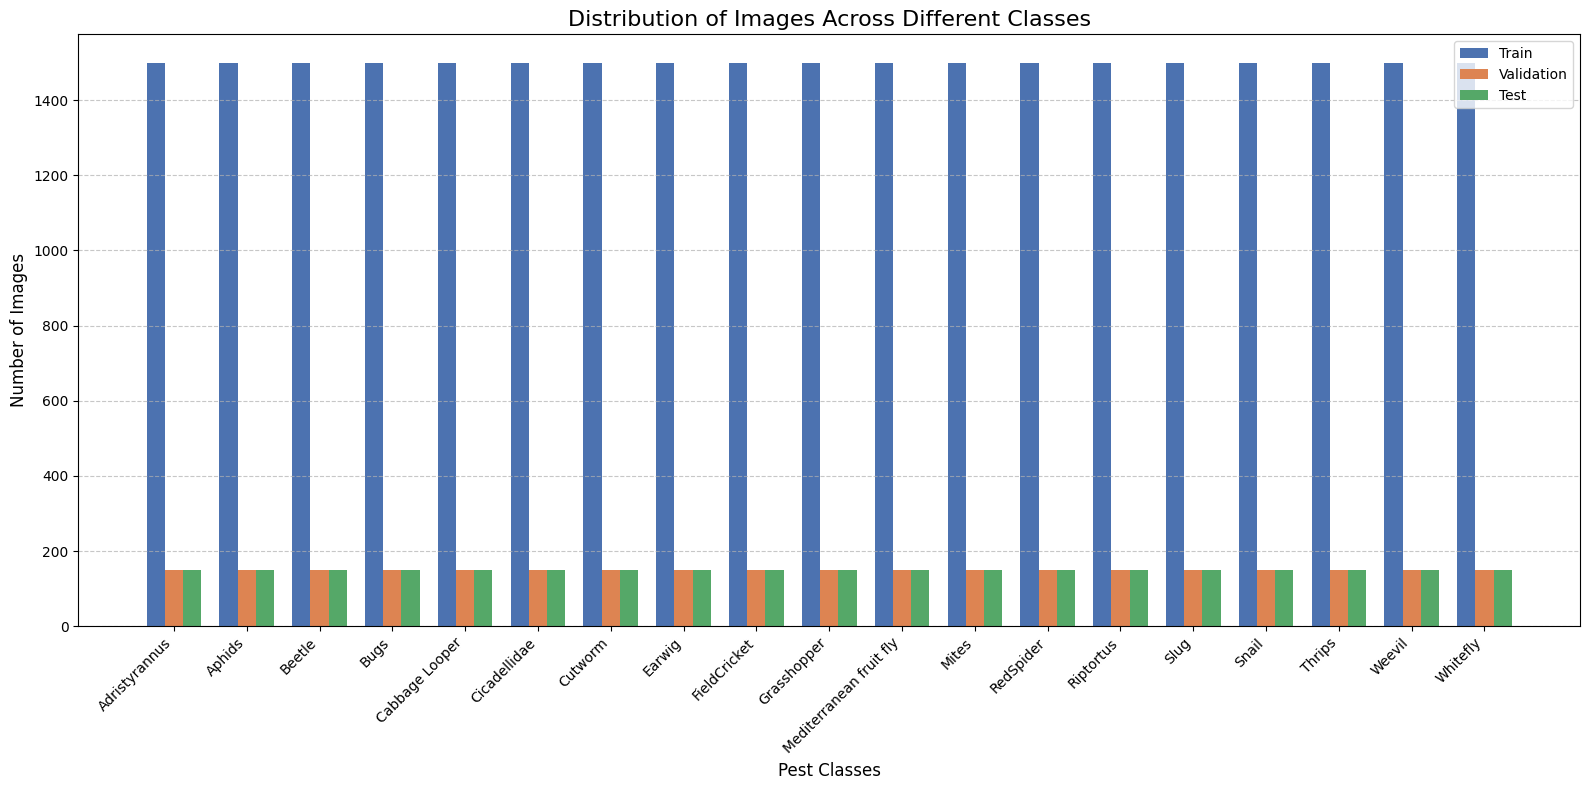

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

base_path = './working/dataset_publish/balanced_pest_dataset'
dirs = ['train', 'val', 'test']
class_counts = {}

# Count images per class for each split
for d in dirs:
    path = os.path.join(base_path, d)
    if not os.path.exists(path):
        print(f"Warning: {path} does not exist. Check Drive sync!")
        continue

    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))])
            if cls not in class_counts:
                class_counts[cls] = {'train': 0, 'val': 0, 'test': 0}
            class_counts[cls][d] = count

if not class_counts:
    print("No classes found. Please verify the dataset path and ensure Drive is mounted and fully synced.")
else:
    classes = list(class_counts.keys())
    train_counts = [class_counts[c]['train'] for c in classes]
    val_counts = [class_counts[c]['val'] for c in classes]
    test_counts = [class_counts[c]['test'] for c in classes]

    # Calculate total images
    total_images = sum(train_counts) + sum(val_counts) + sum(test_counts)
    print(f"### Total Images in Dataset: {total_images} ###\n")

    # Plotting the distribution
    plt.figure(figsize=(16, 8))
    x = np.arange(len(classes))
    width = 0.25

    plt.bar(x - width, train_counts, width, label='Train', color='#4C72B0')
    plt.bar(x, val_counts, width, label='Validation', color='#DD8452')
    plt.bar(x + width, test_counts, width, label='Test', color='#55A868')

    plt.xlabel('Pest Classes', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.title('Distribution of Images Across Different Classes', fontsize=16)
    plt.xticks(x, classes, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Dataset Split and Preprocessing

**How is the dataset split into training and validation sets? Justify your choice.**
* The dataset is pre-split into 28,500 training images, 2,850 validation images, and 2,850 test images. This equates to an approximate 83.3% / 8.3% / 8.3% split.
* **Justification**: This is a robust and highly balanced split. The large training set ensures the model has enough data to learn the complex patterns of 19 different pest classes, while the equivalently sized validation and test sets ensure reliable evaluation and tuning without data leakage.

**What preprocessing techniques were applied?**
* **Resizing**: Images are resized to `224x224` pixels to maintain uniformity and compatibility with standard CNN architectures (like VGG/ResNet for Part B).
* **Normalization**: Pixel values are rescaled from the range [0, 255] to [0, 1] using `rescale=1./255`. This helps the neural network converge faster during training.

**What data generators, if any, were used for preprocessing and augmentation?**
* We use Keras's `ImageDataGenerator`. Since the provided dataset has already been augmented by its creators to balance the classes, we only need to apply normalization (`rescale=1./255`) for the training, validation, and test sets to properly load the images in batches.

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# 1. Training Data Generator (Only Normalization since dataset is already augmented)
train_datagen = ImageDataGenerator(rescale=1./255)

# 2. Validation/Test Data Generator (Only Normalization)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("--- Loading Training Data ---")
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("\n--- Loading Validation Data ---")
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_path, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n--- Loading Test Data ---")
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

--- Loading Training Data ---
Found 28500 images belonging to 19 classes.

--- Loading Validation Data ---
Found 2850 images belonging to 19 classes.

--- Loading Test Data ---
Found 2850 images belonging to 19 classes.


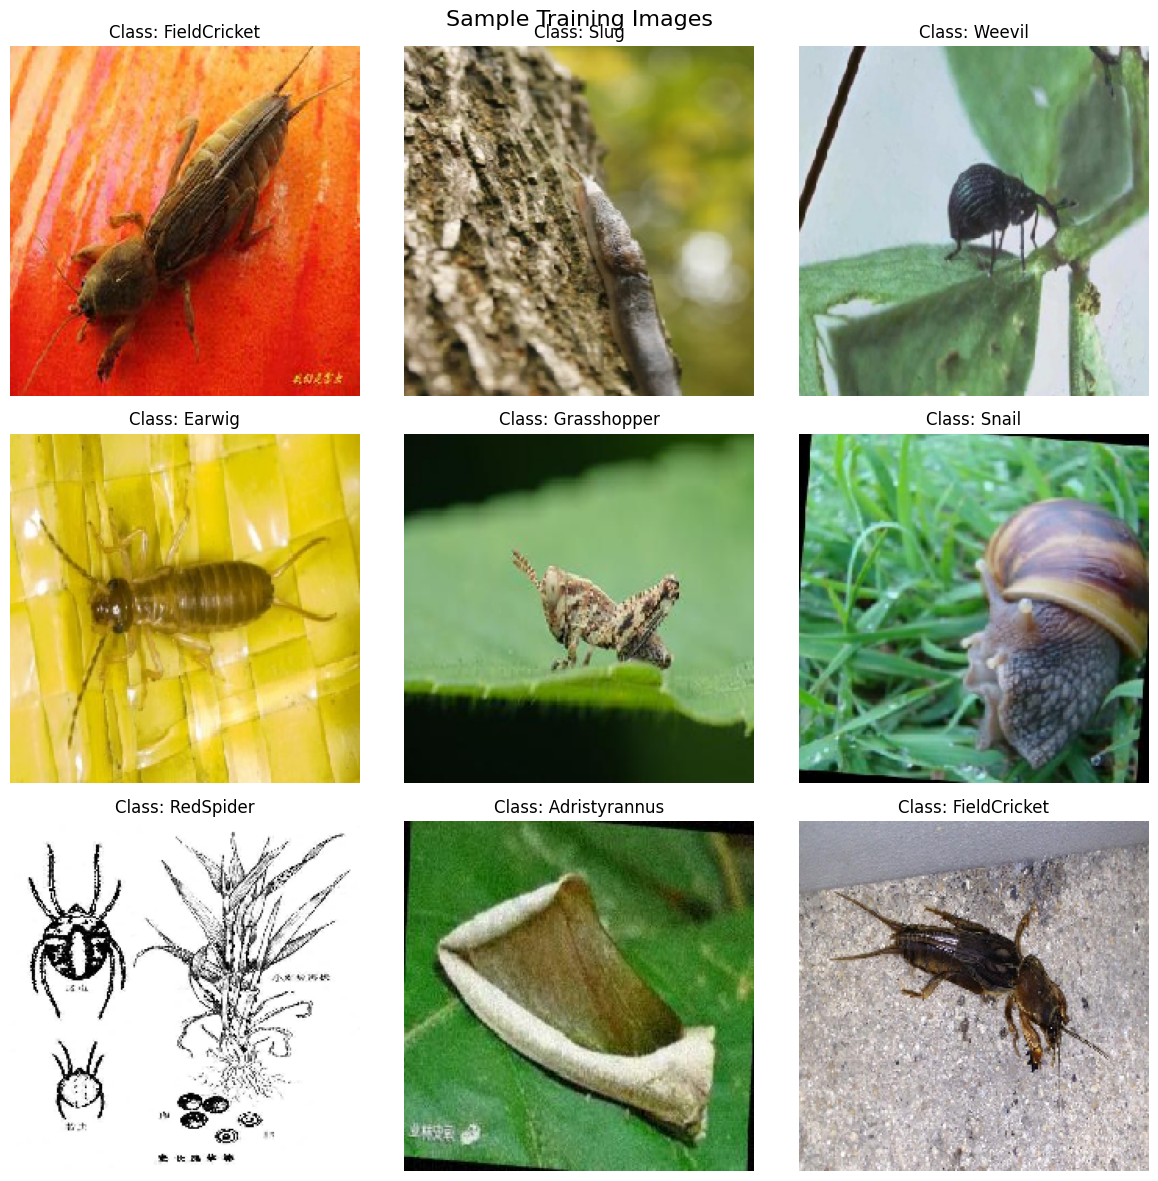

In [3]:
# Fetch a single batch of images and labels from the train generator
images, labels = next(train_generator)

# Get the class dictionary mapping to map indices back to class names
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Plotting 9 sample images
plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    # Decode the one-hot encoded label
    class_idx = np.argmax(labels[i])
    class_name = idx_to_class[class_idx]

    plt.title(f"Class: {class_name}", fontsize=12)
    plt.axis("off")

plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## 1.2 Design, Train, and Evaluate a Baseline Model

### 1. Model Architecture
According to the assignment requirements, the baseline model is built with the following structure:
* **Three Convolutional Layers**: Each is paired with a Max Pooling layer to extract spatial features and downsample the images.
  * **Filters**: 32, 64, and 128 respectively, to learn increasingly complex features.
  * **Kernel Size**: `(3, 3)` for all convolutional layers, a standard choice for image classification.
  * **Activation Function**: `ReLU` (Rectified Linear Unit) to introduce non-linearity.
* **Three Fully Connected Layers (FCN)**: After flattening the 2D feature maps into a 1D vector.
  * **1st FCN**: Dense layer with 128 units, `ReLU` activation.
  * **2nd FCN**: Dense layer with 64 units, `ReLU` activation.
  * **3rd FCN (Output Layer)**: Dense layer with 19 units (matching our 19 pest classes) and `Softmax` activation to output class probabilities.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# 1. Define the baseline model
baseline_model = Sequential([
    # 1st Convolutional Layer + Pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # 2nd Convolutional Layer + Pooling
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # 3rd Convolutional Layer + Pooling
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    # Three Fully Connected Layers (FCN)
    # 1st FCN
    Dense(128, activation='relu'),
    # 2nd FCN
    Dense(64, activation='relu'),
    # 3rd FCN (Output layer)
    Dense(19, activation='softmax')
])

# 2. Compile the model
baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# 3. Print the model summary
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

**Interpretation of the Model Summary:**
* The input images start with a shape of `(224, 224, 3)`.
* As the data passes through the `Conv2D` and `MaxPooling2D` layers, the spatial dimensions shrink (eventually down to `26 x 26`), while the depth (number of feature maps) increases from 3 to 128. This allows the network to summarize local spatial details into rich, abstract features.
* The `Flatten` layer converts the `26x26x128` tensor into a single 1D array of `86528` elements.
* The Dense layers map these learned features to the 19 output classes.
* The model has over 11 million trainable parameters, the vast majority of which come from the connection between the Flatten layer and the first Dense layer.

### 2. Model Training

Next, we train the baseline model. We will train it for 10 epochs as a starting point. We use the training generator for the training data and the validation generator for the validation data.


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

# Pre-built callbacks list to be used across all models
my_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='./best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

EPOCHS = 15

print("Starting training...")
start_time = time.time()

history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

print(f"Training completed in {(time.time() - start_time)/60:.2f} minutes!")


Starting training...
Epoch 1/15
 13/891 [..............................] - ETA: 3:27 - loss: 3.1299 - accuracy: 0.0505

c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment\.venv-gpu\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


891/891 [==============================] - ETA: 0s - loss: 2.3371 - accuracy: 0.2523
Epoch 1: val_loss improved from inf to 2.18507, saving model to .\best_model.keras
891/891 [==============================] - 256s 260ms/step - loss: 2.3371 - accuracy: 0.2523 - val_loss: 2.1851 - val_accuracy: 0.3182
Epoch 2/15
891/891 [==============================] - ETA: 0s - loss: 1.7198 - accuracy: 0.4475
Epoch 2: val_loss improved from 2.18507 to 1.98420, saving model to .\best_model.keras
891/891 [==============================] - 93s 104ms/step - loss: 1.7198 - accuracy: 0.4475 - val_loss: 1.9842 - val_accuracy: 0.4105
Epoch 3/15
891/891 [==============================] - ETA: 0s - loss: 1.2481 - accuracy: 0.5992
Epoch 3: val_loss improved from 1.98420 to 1.94513, saving model to .\best_model.keras
891/891 [==============================] - 91s 102ms/step - loss: 1.2481 - accuracy: 0.5992 - val_loss: 1.9451 - val_accuracy: 0.4481
Epoch 4/15
891/891 [==============================] - ETA: 0s -

In [7]:
import tensorflow as tf

if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print('No GPU found. Please ensure you have selected a GPU runtime.')

Default GPU Device: /device:GPU:0


### 3. Model Evaluation (Baseline)

Let's evaluate the baseline model using the test set to see its performance metrics (Accuracy, Precision, Recall, and F1-Score) and perform inference on a few sample images.

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Evaluating baseline model on Test Data...")
# 1. Evaluate on test set
test_loss, test_acc = baseline_model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Get predictions for Classification Report
print("\nGenerating Classification Report...")
test_generator.reset() # Reset generator to ensure alignment
Y_pred = baseline_model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

target_names = list(test_generator.class_indices.keys())
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

Evaluating baseline model on Test Data...
47/90 [==============>...............] - ETA: 13s - loss: 1.9662 - accuracy: 0.4382

c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment\.venv-gpu\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


90/90 [==============================] - 26s 292ms/step - loss: 1.8529 - accuracy: 0.4747

Test Accuracy: 47.47%
Test Loss: 1.8529

Generating Classification Report...
90/90 [==============================] - 6s 70ms/step
                         precision    recall  f1-score   support

          Adristyrannus       0.71      0.41      0.52       150
                 Aphids       0.45      0.33      0.38       150
                 Beetle       0.33      0.54      0.41       150
                   Bugs       0.58      0.46      0.51       150
         Cabbage Looper       0.85      0.61      0.71       150
           Cicadellidae       0.39      0.49      0.44       150
                Cutworm       0.22      0.37      0.28       150
                 Earwig       0.38      0.23      0.28       150
           FieldCricket       0.46      0.63      0.53       150
            Grasshopper       0.29      0.30      0.30       150
Mediterranean fruit fly       0.78      0.79      0.78       1

1/1 [==============================] - 0s 79ms/step


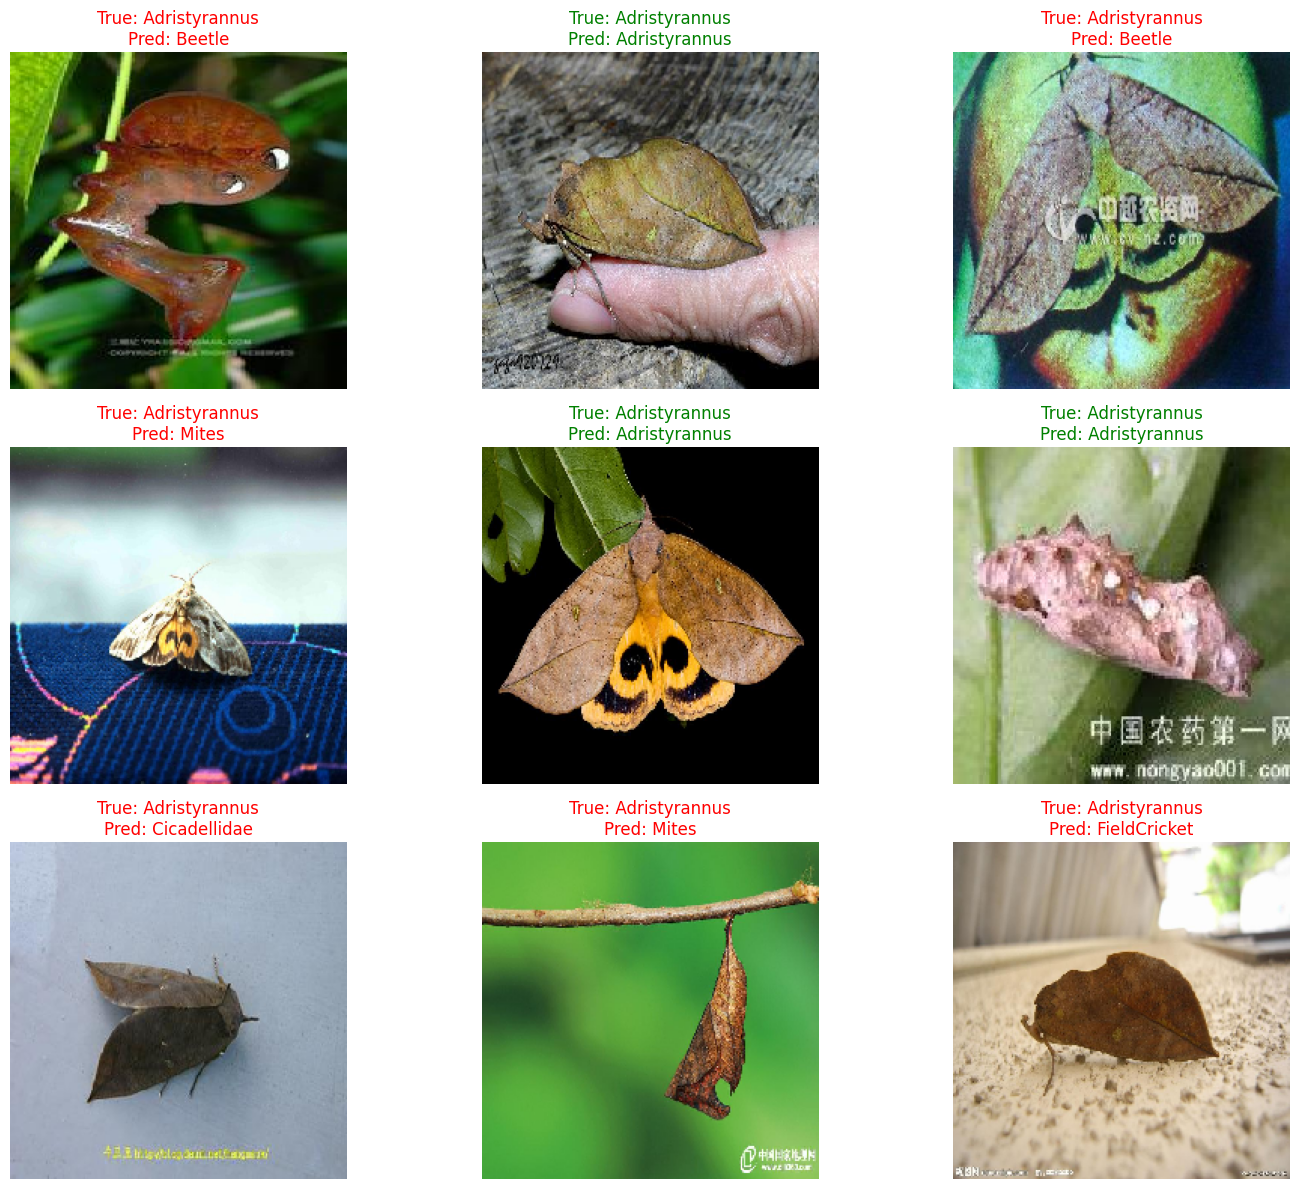

In [10]:
# 3. Perform inference on sample images
test_generator.reset()
images, labels = next(test_generator)

# Predict on the batch
preds = baseline_model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    true_label = target_names[true_classes[i]]
    pred_label = target_names[pred_classes[i]]

    # Color code: Green if correct, Red if incorrect
    color = 'green' if true_label == pred_label else 'red'

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

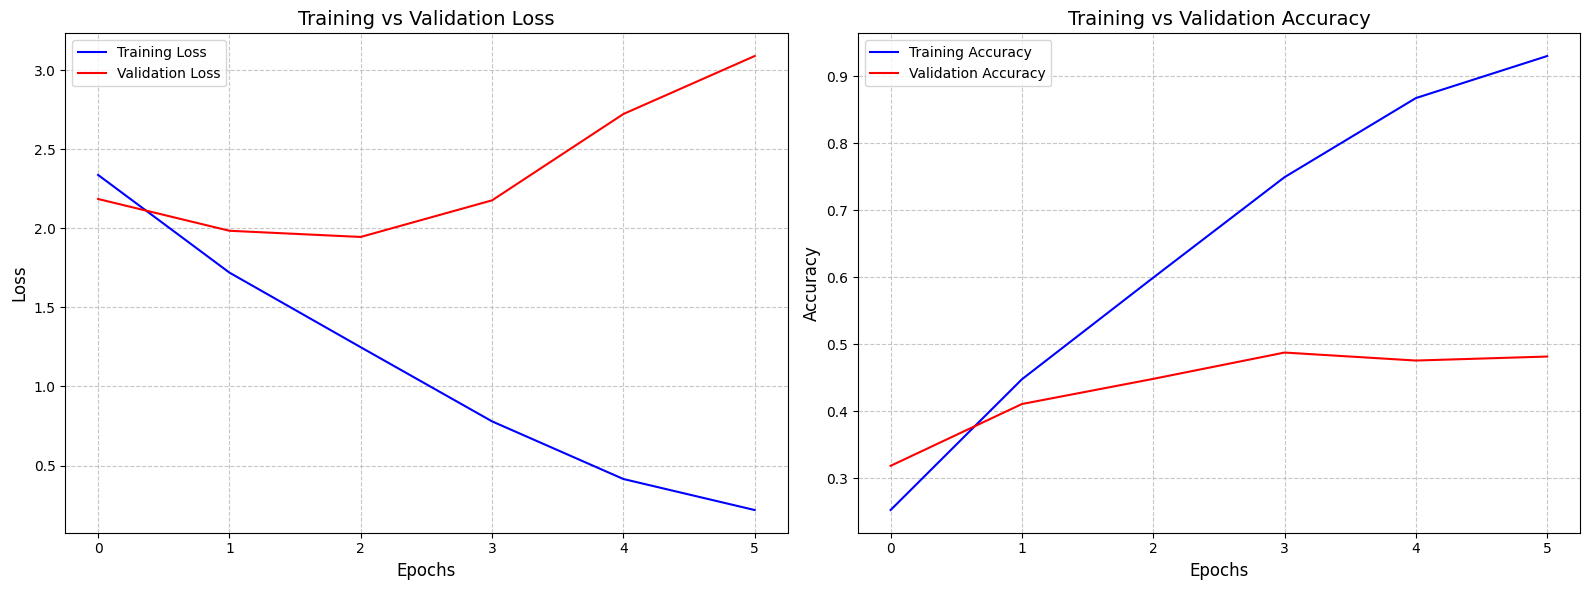

In [11]:
import matplotlib.pyplot as plt

# Plotting Training vs Validation Loss & Accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss Curve
axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red')
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Key Observations about Model Performance (Baseline):**
* *(You can fill this in after viewing the results: e.g., Is it overfitting? Which classes does it struggle with based on the precision/recall metrics? Is the overall accuracy satisfactory for a simple model?)*

## 1.3 Deeper Architecture with Regularization Layer

### 1. Model Architecture
To improve upon the baseline, we will extend the architecture by doubling the number of convolutional layers and introducing regularization techniques to combat overfitting:
* **More Layers & Filters**: Adding a 4th convolutional block with 256 filters.
* **Batch Normalization**: Placed after convolutional layers to stabilize and accelerate training by normalizing the inputs to the next layer.
* **Dropout**: Placed in the fully connected layers (rate=0.5) to randomly drop units during training, preventing the model from becoming overly reliant on specific nodes.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

# Define the Deeper Model
deeper_model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3), padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 4 (New Deep Layer)
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # REPLACE Flatten() with GlobalAveragePooling2D()
    GlobalAveragePooling2D(),

    # Fully Connected Layers with Dropout
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(19, activation='softmax')
])

# Compile the deeper model
deeper_model.compile(optimizer='adam',
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

# Print summary to see the massive drop in total parameters!
deeper_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_4 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 batch_normalization_5 (Batc  (None, 112, 112, 64)     256       
 hNormalization)                                                 
                                                      

### 2. Model Training (Deeper Model)

Now we will train the deeper model for the same number of epochs to compare its performance and training time against the baseline model.

In [17]:
import time

print("Starting training for deeper model...")
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

end_time = time.time()
deeper_training_time = end_time - start_time
print(f"Training completed in {deeper_training_time/60:.2f} minutes!")

Starting training for deeper model...
Epoch 1/15
659/891 [=====================>........] - ETA: 28s - loss: 2.7775 - accuracy: 0.1356

c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment\.venv-gpu\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


891/891 [==============================] - ETA: 0s - loss: 2.7277 - accuracy: 0.1485
Epoch 1: val_loss did not improve from 1.94513
891/891 [==============================] - 116s 129ms/step - loss: 2.7277 - accuracy: 0.1485 - val_loss: 2.5654 - val_accuracy: 0.2130
Epoch 2/15
891/891 [==============================] - ETA: 0s - loss: 2.4220 - accuracy: 0.2293
Epoch 2: val_loss did not improve from 1.94513
891/891 [==============================] - 115s 129ms/step - loss: 2.4220 - accuracy: 0.2293 - val_loss: 2.4136 - val_accuracy: 0.2358
Epoch 3/15
891/891 [==============================] - ETA: 0s - loss: 2.1927 - accuracy: 0.2952
Epoch 3: val_loss did not improve from 1.94513
891/891 [==============================] - 115s 129ms/step - loss: 2.1927 - accuracy: 0.2952 - val_loss: 2.1577 - val_accuracy: 0.3137
Epoch 4/15
891/891 [==============================] - ETA: 0s - loss: 2.0158 - accuracy: 0.3526
Epoch 4: val_loss did not improve from 1.94513
891/891 [=========================

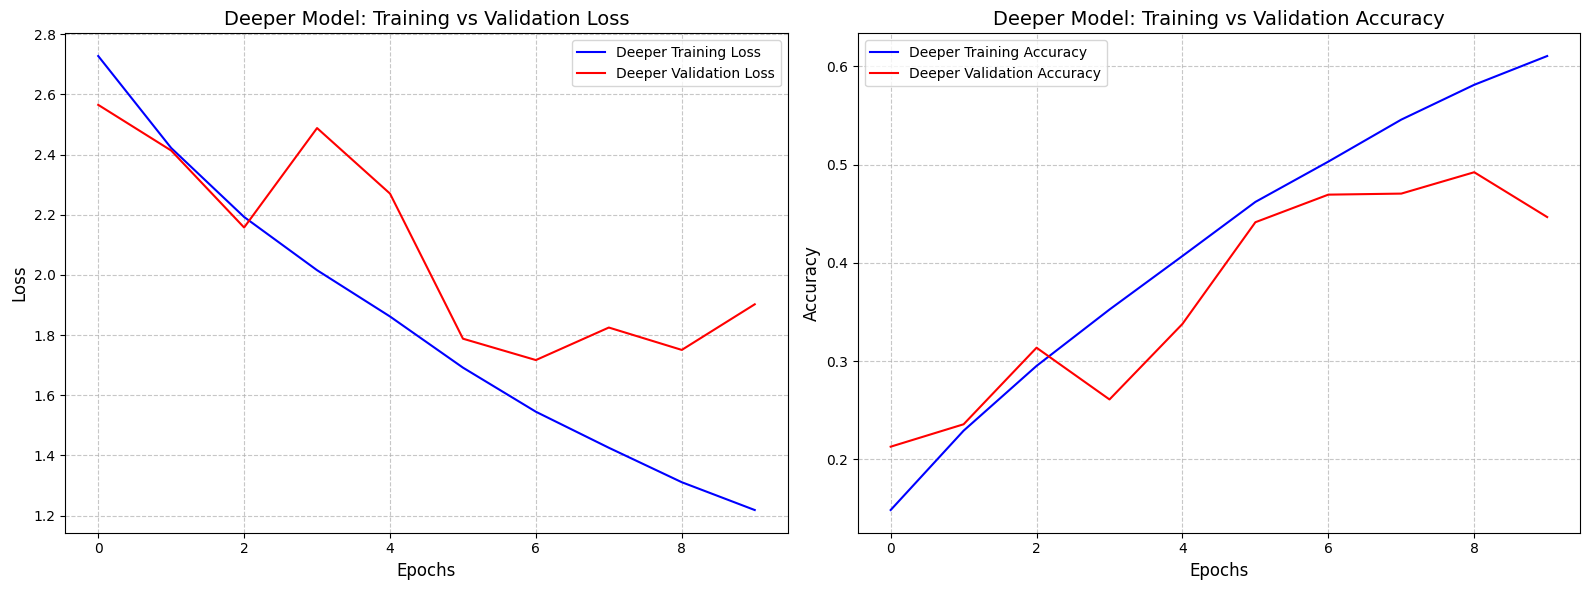

In [18]:
# Plotting Training vs Validation Loss & Accuracy for Deeper Model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss Curve
axes[0].plot(deeper_history.history['loss'], label='Deeper Training Loss', color='blue')
axes[0].plot(deeper_history.history['val_loss'], label='Deeper Validation Loss', color='red')
axes[0].set_title('Deeper Model: Training vs Validation Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Accuracy Curve
axes[1].plot(deeper_history.history['accuracy'], label='Deeper Training Accuracy', color='blue')
axes[1].plot(deeper_history.history['val_accuracy'], label='Deeper Validation Accuracy', color='red')
axes[1].set_title('Deeper Model: Training vs Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3. Model Evaluation (Deeper Model)

In [19]:
print("Evaluating deeper model on Test Data...")
# 1. Evaluate on test set
deeper_test_loss, deeper_test_acc = deeper_model.evaluate(test_generator)
print(f"\nDeeper Model Test Accuracy: {deeper_test_acc*100:.2f}%")
print(f"Deeper Model Test Loss: {deeper_test_loss:.4f}")

# 2. Get predictions for Classification Report
print("\nGenerating Classification Report for Deeper Model...")
test_generator.reset()
Deeper_Y_pred = deeper_model.predict(test_generator)
deeper_y_pred = np.argmax(Deeper_Y_pred, axis=1)

print(classification_report(test_generator.classes, deeper_y_pred, target_names=target_names))

Evaluating deeper model on Test Data...
90/90 [==============================] - 10s 106ms/step - loss: 1.7140 - accuracy: 0.4804

Deeper Model Test Accuracy: 48.04%
Deeper Model Test Loss: 1.7140

Generating Classification Report for Deeper Model...
90/90 [==============================] - 6s 63ms/step
                         precision    recall  f1-score   support

          Adristyrannus       0.70      0.41      0.51       150
                 Aphids       0.32      0.41      0.36       150
                 Beetle       0.45      0.31      0.37       150
                   Bugs       0.69      0.42      0.52       150
         Cabbage Looper       0.65      0.77      0.71       150
           Cicadellidae       0.52      0.31      0.39       150
                Cutworm       0.35      0.24      0.29       150
                 Earwig       0.48      0.38      0.42       150
           FieldCricket       0.37      0.63      0.47       150
            Grasshopper       0.28      0.13

## 1.4 Experimentation and Comparative Analysis


### 1.4.3 Experimentation: Optimizer Analysis (SGD vs Adam)

In the previous section, we trained the deeper model using the **Adam** optimizer. Now, we will re-initialize the same deeper model architecture and train it using **SGD** (Stochastic Gradient Descent) with momentum.

This will allow us to compare how the choice of optimizer affects convergence speed and the final validation accuracy/loss.

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
import time

# 1. Function to build a fresh deeper model (so we don't start with Adam's pre-trained weights)
def build_deeper_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(19, activation='softmax')
    ])
    return model

# 2. Build and compile with SGD
print("Building and compiling Deeper Model with SGD...")
sgd_model = build_deeper_model()

# We use a standard learning rate of 0.01 and momentum of 0.9 for SGD
sgd_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
# 3. Train the SGD model
print("\nStarting training for deeper model with SGD...")
start_time_sgd = time.time()

sgd_history = sgd_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

end_time_sgd = time.time()
sgd_training_time = end_time_sgd - start_time_sgd
print(f"\nSGD Training completed in {sgd_training_time/60:.2f} minutes!")

Building and compiling Deeper Model with SGD...

Starting training for deeper model with SGD...
Epoch 1/15
891/891 [==============================] - ETA: 0s - loss: 3.0687 - accuracy: 0.0504
Epoch 1: val_loss did not improve from 1.71708
891/891 [==============================] - 136s 152ms/step - loss: 3.0687 - accuracy: 0.0504 - val_loss: 2.9447 - val_accuracy: 0.0526
Epoch 2/15
891/891 [==============================] - ETA: 0s - loss: 2.9475 - accuracy: 0.0511
Epoch 2: val_loss did not improve from 1.71708
891/891 [==============================] - 130s 146ms/step - loss: 2.9475 - accuracy: 0.0511 - val_loss: 2.9450 - val_accuracy: 0.0526
Epoch 3/15
891/891 [==============================] - ETA: 0s - loss: 2.9472 - accuracy: 0.0519
Epoch 3: val_loss did not improve from 1.71708
891/891 [==============================] - 135s 151ms/step - loss: 2.9472 - accuracy: 0.0519 - val_loss: 2.9450 - val_accuracy: 0.0526
Epoch 4/15
891/891 [==============================] - ETA: 0s - loss: 

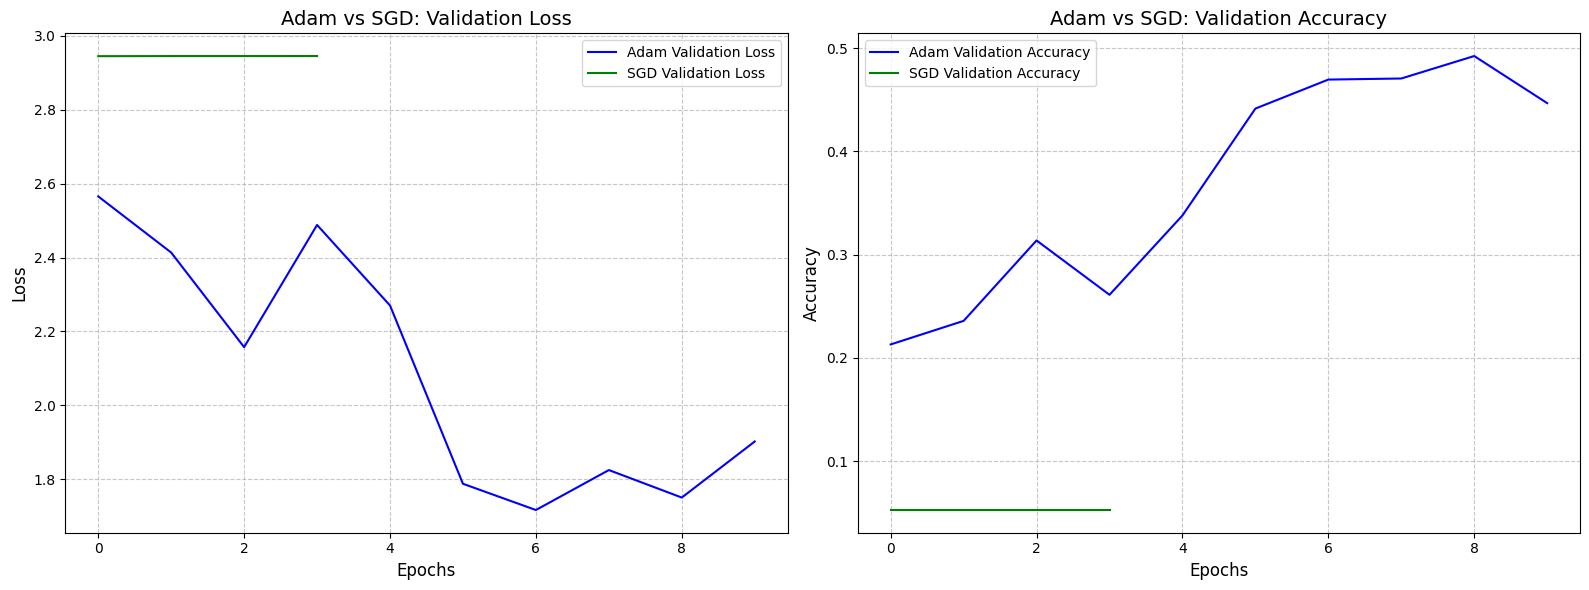

In [22]:
# 4. Plotting the comparison: Adam vs SGD
# Note: This assumes 'deeper_history' (Adam) from the previous section is still in memory.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation Loss Comparison
axes[0].plot(deeper_history.history['val_loss'], label='Adam Validation Loss', color='blue')
axes[0].plot(sgd_history.history['val_loss'], label='SGD Validation Loss', color='green')
axes[0].set_title('Adam vs SGD: Validation Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Validation Accuracy Comparison
axes[1].plot(deeper_history.history['val_accuracy'], label='Adam Validation Accuracy', color='blue')
axes[1].plot(sgd_history.history['val_accuracy'], label='SGD Validation Accuracy', color='green')
axes[1].set_title('Adam vs SGD: Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 1.4 Experimentation: Ablation Study (Removing Dropout)

To understand the contribution of specific architectural choices, we will perform an ablation study. We will take the `deeper_model` architecture and **remove the Dropout layers** from the fully connected layers.

We will train this modified model using Adam (to keep the comparison fair with the original deeper model) and compare their validation curves to see how the absence of dropout affects overfitting.

In [23]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

# 1. Build Ablation Model (No Dropout)
def build_ablation_model_no_dropout():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3), padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation='relu'),
        # Dropout(0.5) layer removed here for ablation study
        Dense(128, activation='relu'),
        # Dropout(0.5) layer removed here for ablation study
        Dense(19, activation='softmax')
    ])
    return model

print("Building Ablation Model (No Dropout)...")
ablation_model = build_ablation_model_no_dropout()

# 2. Compile the Ablation model
print("Compiling Ablation Model...")
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train the Ablation model
print("\nStarting training for ablation model...")
start_time_ablation = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

print(f"\nAblation Training completed in {(time.time() - start_time_ablation)/60:.2f} minutes!")

Building Ablation Model (No Dropout)...
Compiling Ablation Model...

Starting training for ablation model...
Epoch 1/15
891/891 [==============================] - ETA: 0s - loss: 2.9823 - accuracy: 0.1474
Epoch 1: val_loss did not improve from 1.71708
891/891 [==============================] - 138s 154ms/step - loss: 2.9823 - accuracy: 0.1474 - val_loss: 2.6060 - val_accuracy: 0.1604
Epoch 2/15
891/891 [==============================] - ETA: 0s - loss: 2.3784 - accuracy: 0.2142
Epoch 2: val_loss did not improve from 1.71708
891/891 [==============================] - 126s 142ms/step - loss: 2.3784 - accuracy: 0.2142 - val_loss: 2.4819 - val_accuracy: 0.2049
Epoch 3/15
891/891 [==============================] - ETA: 0s - loss: 2.1478 - accuracy: 0.2947
Epoch 3: val_loss did not improve from 1.71708
891/891 [==============================] - 126s 141ms/step - loss: 2.1478 - accuracy: 0.2947 - val_loss: 2.4310 - val_accuracy: 0.2326
Epoch 4/15
891/891 [==============================] - ETA

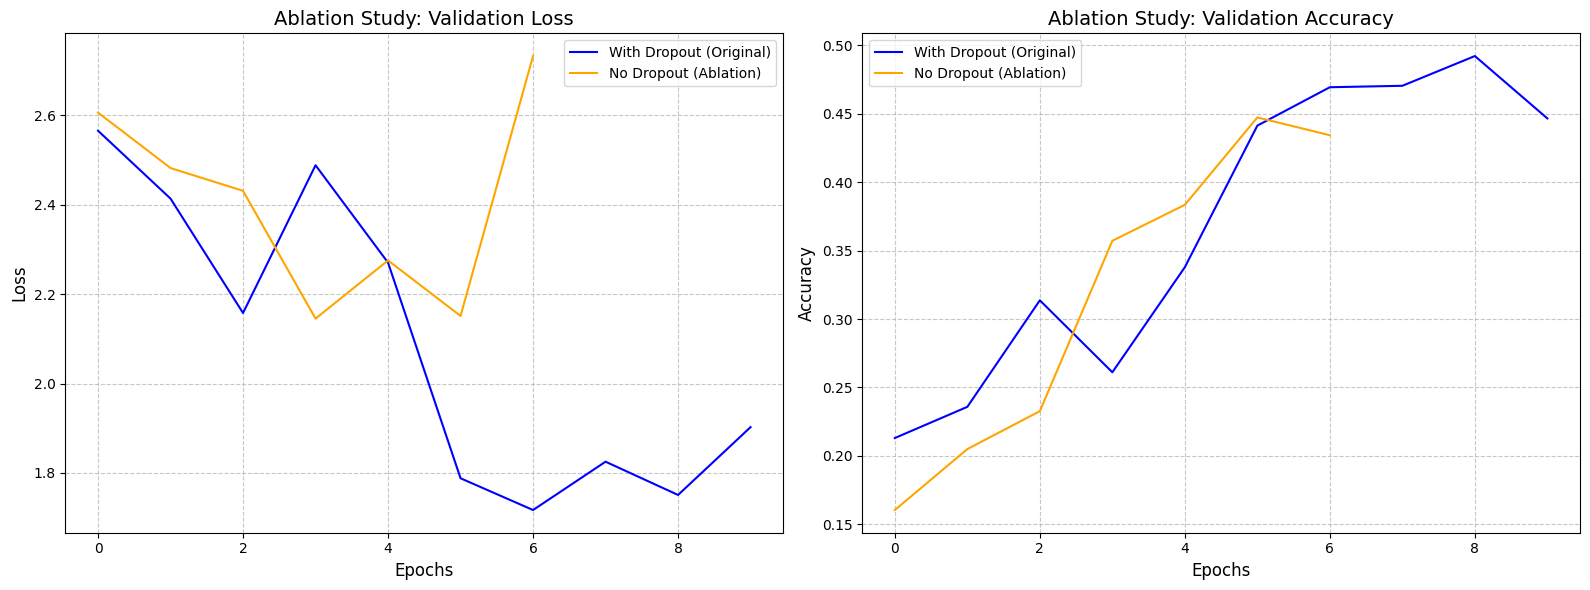

In [24]:
# 3. Plotting the comparison: Original Deeper (with Dropout) vs Ablation (No Dropout)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation Loss Comparison
axes[0].plot(deeper_history.history['val_loss'], label='With Dropout (Original)', color='blue')
axes[0].plot(ablation_history.history['val_loss'], label='No Dropout (Ablation)', color='orange')
axes[0].set_title('Ablation Study: Validation Loss', fontsize=14)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Validation Accuracy Comparison
axes[1].plot(deeper_history.history['val_accuracy'], label='With Dropout (Original)', color='blue')
axes[1].plot(ablation_history.history['val_accuracy'], label='No Dropout (Ablation)', color='orange')
axes[1].set_title('Ablation Study: Validation Accuracy', fontsize=14)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#2 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

For this section, we will use **MobileNetV2** as our pre-trained model. It is a lightweight, highly efficient architecture pre-trained on ImageNet, making it an excellent choice for this task.


### 2.1 & 2.2 Phase 1: Feature Extraction
First, we load the MobileNetV2 base model without its top classification layers (`include_top=False`). We freeze these base layers so their pre-trained weights are not updated during the first phase of training. We then attach our own Dense layers to classify the 19 pest categories.

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load the pre-trained MobileNetV2 base model
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))

# 2. Freeze the base model (Feature Extraction)
base_model.trainable = False

# 3. Add custom classification head for our 19 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Replaces Flatten, more robust to overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(19, activation='softmax')(x)

# Combine the base model and the new layers
transfer_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model for Feature Extraction
transfer_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("MobileNetV2 Base Model loaded and frozen. Custom head added.")
transfer_model.summary()

9406464/9406464 [==============================] - 0s 0us/step
MobileNetV2 Base Model loaded and frozen. Custom head added.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Co

### 2.2 Phase 2: Fine-Tuning

After training the top layers, we can now gently **fine-tune** the top layers of the MobileNetV2 base.
We will unfreeze the model, but keep the initial layers frozen (as they contain generic features like edges and curves). We will unfreeze from layer 100 onwards and use a much smaller learning rate (`1e-5`) to avoid destroying the pre-trained weights (catastrophic forgetting).

In [28]:
import time

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze all layers EXCEPT the top ones (e.g., from layer 100 onwards)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Re-compile with a MUCH LOWER learning rate for fine-tuning
transfer_model.compile(optimizer=Adam(learning_rate=1e-5),  # Lower learning rate
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print(f"Model re-compiled for fine-tuning. Trainable layers: {len(transfer_model.trainable_variables)}")

# 4. Train for fine-tuning phase
FINE_TUNE_EPOCHS = 20

print("\nStarting Fine-Tuning Phase...")
start_time_ft = time.time()

history_fine_tuning = transfer_model.fit(
    train_generator,
    epochs=FINE_TUNE_EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

print(f"\nFine-Tuning completed in {(time.time() - start_time_ft)/60:.2f} minutes!")

Model re-compiled for fine-tuning. Trainable layers: 58

Starting Fine-Tuning Phase...
Epoch 1/20
124/891 [===>..........................] - ETA: 1:56 - loss: 0.2840 - accuracy: 0.9118

c:\Users\Hp\Desktop\Herald\Final Year\AIML\Assessment\.venv-gpu\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


891/891 [==============================] - ETA: 0s - loss: 0.2779 - accuracy: 0.9144
Epoch 1: val_loss did not improve from 0.61550
891/891 [==============================] - 162s 178ms/step - loss: 0.2779 - accuracy: 0.9144 - val_loss: 0.6158 - val_accuracy: 0.8270
Epoch 2/20
891/891 [==============================] - ETA: 0s - loss: 0.2445 - accuracy: 0.9252
Epoch 2: val_loss improved from 0.61550 to 0.61259, saving model to .\best_model.keras
891/891 [==============================] - 155s 173ms/step - loss: 0.2445 - accuracy: 0.9252 - val_loss: 0.6126 - val_accuracy: 0.8291
Epoch 3/20
891/891 [==============================] - ETA: 0s - loss: 0.2191 - accuracy: 0.9306
Epoch 3: val_loss did not improve from 0.61259
891/891 [==============================] - 143s 160ms/step - loss: 0.2191 - accuracy: 0.9306 - val_loss: 0.6193 - val_accuracy: 0.8281
Epoch 4/20
891/891 [==============================] - ETA: 0s - loss: 0.1944 - accuracy: 0.9402
Epoch 4: val_loss did not improve from 0.

In [29]:
# 2.3 Model Evaluation and Prediction

print("Evaluating Fine-Tuned MobileNetV2 on Test Data...")
# 1. Evaluate on test set
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_generator)
print(f"\nTransfer Learning Model Test Accuracy: {transfer_test_acc*100:.2f}%")
print(f"Transfer Learning Model Test Loss: {transfer_test_loss:.4f}")

# 2. Get predictions for Classification Report
print("\nGenerating Classification Report for Transfer Learning Model...")
test_generator.reset()
Transfer_Y_pred = transfer_model.predict(test_generator)
transfer_y_pred = np.argmax(Transfer_Y_pred, axis=1)

print(classification_report(test_generator.classes, transfer_y_pred, target_names=target_names))

Evaluating Fine-Tuned MobileNetV2 on Test Data...
90/90 [==============================] - 9s 104ms/step - loss: 0.5209 - accuracy: 0.8372

Transfer Learning Model Test Accuracy: 83.72%
Transfer Learning Model Test Loss: 0.5209

Generating Classification Report for Transfer Learning Model...
90/90 [==============================] - 9s 91ms/step
                         precision    recall  f1-score   support

          Adristyrannus       0.96      0.87      0.91       150
                 Aphids       0.67      0.82      0.74       150
                 Beetle       0.70      0.73      0.71       150
                   Bugs       0.92      0.85      0.89       150
         Cabbage Looper       0.95      0.87      0.91       150
           Cicadellidae       0.82      0.82      0.82       150
                Cutworm       0.83      0.83      0.83       150
                 Earwig       0.84      0.78      0.81       150
           FieldCricket       0.84      0.90      0.87       150
  

Evaluating Baseline Model...
90/90 [==============================] - 7s 76ms/step - loss: 1.9451 - accuracy: 0.4481

Evaluating No Dropout Model...
90/90 [==============================] - 6s 68ms/step - loss: 2.1452 - accuracy: 0.3572

Evaluating Deeper Model (Adam)...
90/90 [==============================] - 6s 67ms/step - loss: 1.7171 - accuracy: 0.4695

Evaluating Deeper Model (SGD)...
90/90 [==============================] - 6s 69ms/step - loss: 2.9447 - accuracy: 0.0526

Evaluating Transfer Learning Model...
90/90 [==============================] - 9s 94ms/step - loss: 0.6126 - accuracy: 0.8291


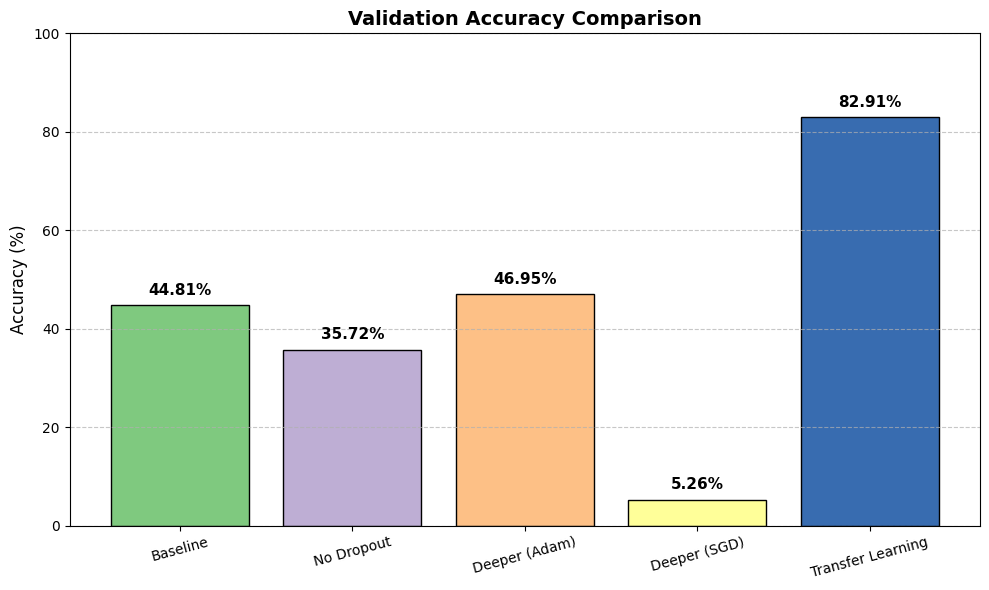

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_1 = baseline_model
model_2 = ablation_model
model_3 = deeper_model
model_4 = sgd_model
model_5 = transfer_model        

# 1. Evaluate all five models on the validation set
print("Evaluating Baseline Model...")
val_generator.reset()
_, baseline_acc = model_1.evaluate(val_generator)

print("\nEvaluating No Dropout Model...")
val_generator.reset()
_, no_drop_acc = model_2.evaluate(val_generator) 

print("\nEvaluating Deeper Model (Adam)...")
val_generator.reset()
_, adam_acc = model_3.evaluate(val_generator)

print("\nEvaluating Deeper Model (SGD)...")
val_generator.reset()
_, sgd_acc = model_4.evaluate(val_generator)

print("\nEvaluating Transfer Learning Model...")
val_generator.reset()
_, tl_acc = model_5.evaluate(val_generator)

# 2. Prepare Data for Plotting
models = ['Baseline', 'No Dropout', 'Deeper (Adam)', 'Deeper (SGD)', 'Transfer Learning']
accuracies = [baseline_acc * 100, no_drop_acc * 100, adam_acc * 100, sgd_acc * 100, tl_acc * 100]

# 3. Create the Comparison Bar Chart (Accuracy Only to save space)
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, accuracies, color=['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0'], edgecolor='black')
ax.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Slightly rotate labels so they don't overlap
ax.tick_params(axis='x', rotation=15)

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f'{yval:.2f}%', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


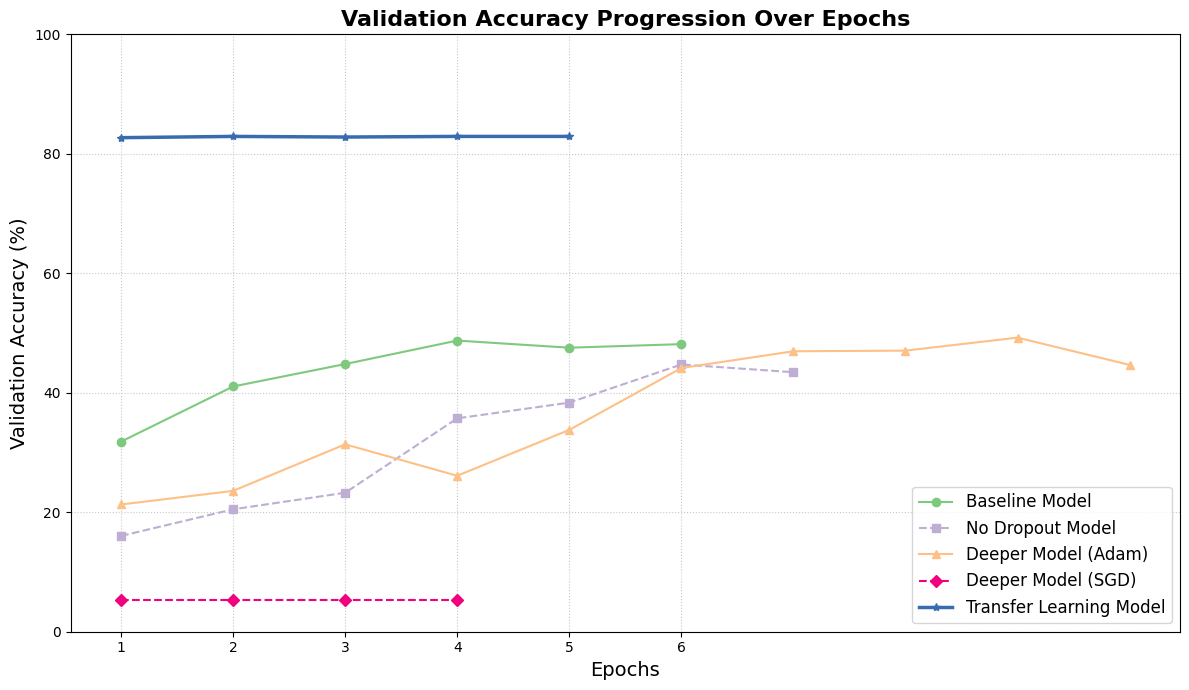

In [32]:
import matplotlib.pyplot as plt

hist_1 = history
hist_2 = ablation_history
hist_3 = deeper_history
hist_4 = sgd_history
hist_5 = history_fine_tuning

# 2. Extract Validation Accuracy arrays for the graph
# (We multiply by 100 to show percentages)
val_acc_1 = [acc * 100 for acc in hist_1.history['val_accuracy']]
val_acc_2 = [acc * 100 for acc in hist_2.history['val_accuracy']]
val_acc_3 = [acc * 100 for acc in hist_3.history['val_accuracy']]
val_acc_4 = [acc * 100 for acc in hist_4.history['val_accuracy']]
val_acc_5 = [acc * 100 for acc in hist_5.history['val_accuracy']]

# 3. Create the Line Graph
plt.figure(figsize=(12, 7))

# Plot lines with different markers to easily tell them apart
plt.plot(val_acc_1, label='Baseline Model', linestyle='-', marker='o', color='#7fc97f')
plt.plot(val_acc_2, label='No Dropout Model', linestyle='--', marker='s', color='#beaed4')
plt.plot(val_acc_3, label='Deeper Model (Adam)', linestyle='-', marker='^', color='#fdc086')
plt.plot(val_acc_4, label='Deeper Model (SGD)', linestyle='--', marker='D', color='#f0027f')
plt.plot(val_acc_5, label='Transfer Learning Model', linestyle='-', marker='*', color='#386cb0', linewidth=2.5)

# Formatting
plt.title('Validation Accuracy Progression Over Epochs', fontsize=16, fontweight='bold')
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Validation Accuracy (%)', fontsize=14)
plt.ylim(0, 100)

# Make the x-axis show whole numbers for epochs (Epoch 1, Epoch 2, etc.)
# We use the length of the baseline history as the default x-axis length
plt.xticks(range(len(val_acc_1)), [str(i+1) for i in range(len(val_acc_1))])

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='lower right')

plt.tight_layout()
plt.show()
